<a href="https://colab.research.google.com/github/irhamaam460-maker/soal-no-1/blob/main/soal_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan upload satu citra grayscale (.jpg atau .png):


Saving Screenshot 2026-03-31 150247.png to Screenshot 2026-03-31 150247.png


/tmp/ipykernel_11011/4209489183.py:21: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_11011/4209489183.py:21: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_11011/4209489183.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(figures[i].ravel(), 256, [0, 256])


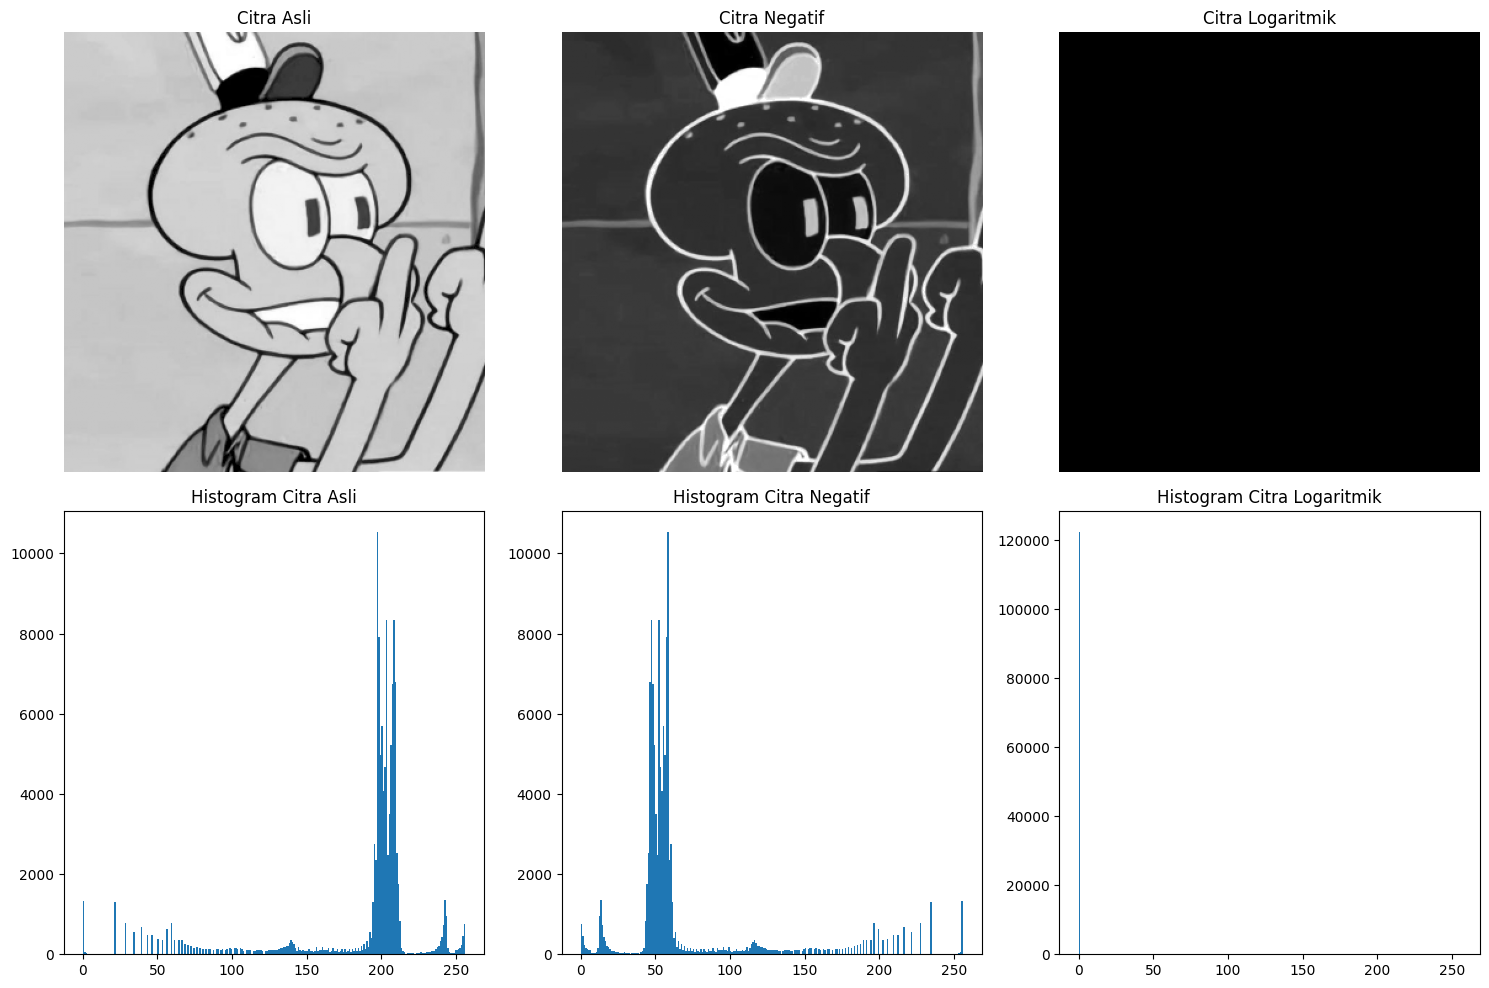

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import io

# 1. Langkah Upload File
print("Silakan upload satu citra grayscale (.jpg atau .png):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Baca citra yang diupload sebagai grayscale
img = cv2.imdecode(np.frombuffer(uploaded[file_name], np.uint8), cv2.IMREAD_GRAYSCALE)

# 2. Terapkan rumus [cite: 22, 23]
# Citra Negatif: G = 255 - F
img_negative = 255 - img

# Transformasi Logaritmik: G = c * log(1 + F)
# c = 255 / log(1 + max(F))
c = 255 / np.log(1 + np.max(img))
img_log = c * (np.log(1 + img.astype(np.float64)))
img_log = np.array(img_log, dtype=np.uint8)

# 3. Tampilkan Citra dan Histogram [cite: 24]
figures = [img, img_negative, img_log]
titles = ['Citra Asli', 'Citra Negatif', 'Citra Logaritmik']

plt.figure(figsize=(15, 10))
for i in range(3):
    # Plot Gambar
    plt.subplot(2, 3, i+1)
    plt.imshow(figures[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

    # Plot Histogram
    plt.subplot(2, 3, i+4)
    plt.hist(figures[i].ravel(), 256, [0, 256])
    plt.title('Histogram ' + titles[i])

plt.tight_layout()
plt.show()